# Data Wrangling Project

## Exploring Movie Characteristics on Netflix vs General Movies Dataset

## 1. Problem Statement

This project aims to explore how Netflix-listed movies compare with general movie metadata in terms of popularity, ratings, and runtime. Specifically, it investigates whether movies available on Netflix differ from the broader movie dataset.

To answer this question, two datasets will be gathered and wrangled: the Netflix Movies and TV Shows dataset and The Movies Dataset. These datasets will be cleaned, assessed, and combined to support analysis and visualization.

## 2. Data Gathering

In this section, two datasets were gathered using different methods to meet the project requirements.

### Dataset 1: Netflix Movies and TV Shows

The Netflix dataset was selected because it contains information about movies and TV shows available on the Netflix platform, including title, release year, duration, and country. This dataset helps identify Netflix-listed movies for comparison.

The dataset was gathered through manual download from Kaggle in CSV format.

---

### Dataset 2: The Movies Dataset

The Movies Dataset was selected because it provides detailed metadata about movies, such as popularity, vote average, runtime, and release date. This dataset allows for a broader comparison with Netflix movies.

The dataset was gathered programmatically using the Kaggle API and then extracted locally for use in this project.

In [72]:

import pandas as pd
import numpy as np

In [73]:
# Load Netflix dataset (manual)
netflix = pd.read_csv("netflix_titles.csv")
netflix.head()



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Loading the Data

After gathering the datasets, they were loaded into pandas DataFrames for initial inspection.  
Only the columns relevant to the research question were selected from *The Movies Dataset* to improve efficiency and focus the analysis on important movie characteristics such as popularity, ratings, runtime, and release date.

In [74]:
# Download dataset using Kaggle API
!kaggle datasets download -d rounakbanik/the-movies-dataset

# Extract files
import zipfile
with zipfile.ZipFile("the-movies-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

Dataset URL: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
License(s): CC0-1.0
the-movies-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [75]:

movies = pd.read_csv(
    "movies_metadata.csv",
    usecols=["title", "release_date", "popularity", "vote_average", "vote_count", "runtime", "genres"],
    low_memory=True
)

movies.head()

C:\Users\u\AppData\Local\Temp\ipykernel_22236\743421848.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies = pd.read_csv(


,genres,popularity,release_date,runtime,title,vote_average,vote_count
0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",21.946943,1995-10-30,81.0,Toy Story,7.7,5415.0
1,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",17.015539,1995-12-15,104.0,Jumanji,6.9,2413.0
2,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",11.7129,1995-12-22,101.0,Grumpier Old Men,6.5,92.0
3,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",3.859495,1995-12-22,127.0,Waiting to Exhale,6.1,34.0
4,"[{'id': 35, 'name': 'Comedy'}]",8.387519,1995-02-10,106.0,Father of the Bride Part II,5.7,173.0


In [76]:
# Check dataset dimensions
print("Netflix shape:", netflix.shape)
print("Movies shape:", movies.shape)

Netflix shape: (8807, 12)
Movies shape: (45466, 7)


In [77]:
# Check basic information
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [78]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   genres        45466 non-null  object 
 1   popularity    45461 non-null  object 
 2   release_date  45379 non-null  object 
 3   runtime       45203 non-null  float64
 4   title         45460 non-null  object 
 5   vote_average  45460 non-null  float64
 6   vote_count    45460 non-null  float64
dtypes: float64(3), object(4)
memory usage: 2.4+ MB


## 4. Assessing Data

In this step, both datasets are assessed visually and programmatically to identify data quality and tidiness issues that may affect the analysis.

The datasets were examined using methods such as `.info()`, `.head()`, and summary checks for missing values and data types.

### Data Quality Issues

1. Missing Values:
Several columns in both datasets contain missing values. For example, the "director", "cast", and "country" columns in the Netflix dataset have missing entries. Similarly, the Movies dataset has missing values in columns such as "release_date" and "runtime".

2. Incorrect Data Types:
The "popularity" column in the Movies dataset is stored as an object instead of a numeric data type, which can affect calculations and analysis.

In [79]:
# Missing values check
netflix.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [80]:
movies.isnull().sum()

genres            0
popularity        5
release_date     87
runtime         263
title             6
vote_average      6
vote_count        6
dtype: int64

In [81]:
# Check data types
movies.dtypes

genres           object
popularity       object
release_date     object
runtime         float64
title            object
vote_average    float64
vote_count      float64
dtype: object

In [82]:
# Example of problematic column
movies["genres"].head()

0    [{'id': 16, 'name': 'Animation'}, {'id': 35, '...
1    [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...
2    [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...
3    [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...
4                       [{'id': 35, 'name': 'Comedy'}]
Name: genres, dtype: object

## Data Quality Issues

1. Missing Values:
The Netflix dataset contains missing values in columns such as country, director,
and cast. The Movies dataset also has missing values in columns like runtime and
release_date. These missing values can affect the accuracy of analysis.

2. Incorrect Data Types:
The popularity column in the Movies dataset is stored as an object instead of
a numeric type, which prevents proper numerical analysis.

---

## Data Tidiness Issues

1. Genres Column Structure:
The genres column contains JSON-like structures instead of simple values,
which violates the rule that each cell should contain a single atomic value.

2. Duration Format:
The duration column in the Netflix dataset contains mixed formats such as
"90 min" and "2 Seasons", making it inconsistent and difficult to analyze.

3. Mixed Observational Units in the Netflix Dataset:
The Netflix dataset contains both Movies and TV Shows in a single table.
These are different types of observations with different attributes, which
violates the tidy rule that each type of observational unit should form
its own table.


## Justification of Methods

Programmatic methods such as .isnull() and .info() were used to identify missing values and data types because they provide a quick and reliable summary of the dataset.

Visual methods such as bar plots were used to better understand the distribution of missing values across columns, making it easier to identify which columns require cleaning.

## 5. Cleaning Data

In this step, the identified data quality and tidiness issues are addressed. Each cleaning step is applied carefully and validated to ensure the dataset is suitable for analysis.

In [83]:
# Make a copy first
netflix_clean = netflix.copy()

# Drop rows with missing titles
netflix_clean = netflix_clean.dropna(subset=["title"])

# Fill missing values in selected columns
netflix_clean["country"] = netflix_clean["country"].fillna("Unknown")
netflix_clean["director"] = netflix_clean["director"].fillna("Not Given")
netflix_clean["cast"] = netflix_clean["cast"].fillna("Not Available")
netflix_clean["rating"] = netflix_clean["rating"].fillna("Unknown")

# For date_added and duration, drop rows because they are useful for analysis
netflix_clean = netflix_clean.dropna(subset=["date_added", "duration"])

# Validate
netflix_clean.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### Cleaning Missing Values (Netflix Dataset)

Missing values were identified in several columns such as "country" and "director". Missing values in "country" were replaced with "Unknown", while missing values in "director" were replaced with "Not Given". Rows with missing titles were removed as the title is a critical field.

In [84]:
# Make a copy of the Movies dataset
movies_clean = movies.copy()

# Convert popularity to numeric
movies_clean["popularity"] = pd.to_numeric(movies_clean["popularity"], errors="coerce")

# Validate data types
movies_clean.dtypes

genres           object
popularity      float64
release_date     object
runtime         float64
title            object
vote_average    float64
vote_count      float64
dtype: object

### Fixing Data Types (Movies Dataset)

The "popularity" column was converted from object to numeric format using pandas. Invalid values were coerced into NaN to ensure proper numerical analysis.

In [85]:
import ast

def extract_genres(x):
    try:
        genres_list = ast.literal_eval(x)
        return ", ".join([i["name"] for i in genres_list])
    except:
        return None

movies_clean["genres"] = movies_clean["genres"].apply(extract_genres)

# Validate genres cleaning
movies_clean["genres"].head()

0     Animation, Comedy, Family
1    Adventure, Fantasy, Family
2               Romance, Comedy
3        Comedy, Drama, Romance
4                        Comedy
Name: genres, dtype: object

### Cleaning Genres Column

The "genres" column contained JSON-like structures. These were converted into a readable comma-separated format by extracting only the genre names.

In [86]:
# Fill missing runtime values with the median
movies_clean["runtime"] = movies_clean["runtime"].fillna(movies_clean["runtime"].median())

# Drop rows missing important columns
movies_clean = movies_clean.dropna(subset=["title", "vote_average"])

# Keep only relevant columns
movies_clean = movies_clean[["title", "release_date", "popularity", "vote_average", "runtime", "genres"]]

# Validate Movies cleaning
movies_clean.isnull().sum()

title            0
release_date    84
popularity       0
vote_average     0
runtime          0
genres           0
dtype: int64

### Handling Missing Values in the Movies Dataset

Missing values in the numeric `runtime` column were replaced with the median because it is a numerical variable and the median is robust to outliers. Rows missing essential values such as `title` and `vote_average` were removed. Only relevant variables were retained for the analysis.

A small number of missing values (84) were found in the "release_date" column, which represents a very small portion of the dataset. Therefore, these values were left unchanged as they do not significantly impact the analysis.

In [87]:
# Keep only movies from Netflix
netflix_movies = netflix_clean[netflix_clean["type"] == "Movie"].copy()

# Convert duration from text to numeric minutes
netflix_movies["duration"] = netflix_movies["duration"].str.replace(" min", "", regex=False)
netflix_movies["duration"] = pd.to_numeric(netflix_movies["duration"], errors="coerce")

# Keep only relevant columns
netflix_movies = netflix_movies[["title", "release_year", "country", "duration"]]

# Validate Netflix movies dataset
netflix_movies.head()

,title,release_year,country,duration
0,Dick Johnson Is Dead,2020,United States,90
6,My Little Pony: A New Generation,2021,Unknown,91
7,Sankofa,1993,"United States, Ghana, Burkina Faso, United Kin...",125
9,The Starling,2021,United States,104
12,Je Suis Karl,2021,"Germany, Czech Republic",127


### Filtering the Netflix Dataset to Movies Only

Since the analysis focuses on movies, the Netflix dataset was filtered to include only rows where `type` is `Movie`. The `duration` column was then converted from text format such as `"90 min"` into numeric minutes.

In [88]:
# Merge cleaned datasets using title
merged = pd.merge(netflix_movies, movies_clean, on="title", how="inner")

# Validate merge
merged.head()

,title,release_year,country,duration,release_date,popularity,vote_average,runtime,genres
0,Sankofa,1993,"United States, Ghana, Burkina Faso, United Kin...",125,1993-05-28,0.045860,6.9,124.0,Drama
1,Grown Ups,2010,United States,103,2010-06-24,23.981251,6.0,102.0,Comedy
2,Dark Skies,2013,United States,97,2013-02-21,26.972326,6.1,97.0,"Science Fiction, Thriller, Horror"
3,Paranoia,2013,"United States, India, France",106,2013-08-14,7.249581,5.6,106.0,"Drama, Thriller"
4,Paranoia,2013,"United States, India, France",106,1969-02-07,2.262992,6.2,91.0,"Thriller, Drama, Romance"


In [89]:
# Add a column to identify Netflix movies
movies_clean["on_netflix"] = movies_clean["title"].isin(netflix_movies["title"])

# Check distribution
movies_clean["on_netflix"].value_counts()

on_netflix
False    42916
True      2544
Name: count, dtype: int64

In [90]:
merged.shape

(2544, 9)

In [91]:
# Save cleaned datasets
netflix_movies.to_csv("cleaned_netflix.csv", index=False)
movies_clean.to_csv("cleaned_movies.csv", index=False)
merged.to_csv("final_merged.csv", index=False)

### Merging the Cleaned Datasets

The cleaned Netflix movies dataset was merged with the cleaned movies metadata dataset using the `title` column. This produced a final merged dataset that combines Netflix-specific information with broader movie characteristics.

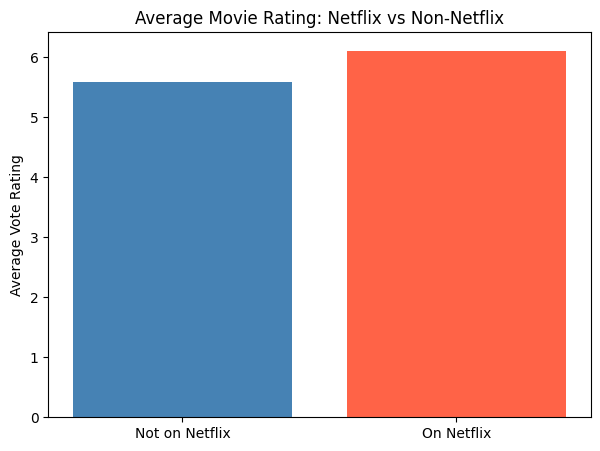

In [92]:
import matplotlib.pyplot as plt

avg_rating = movies_clean.groupby("on_netflix")["vote_average"].mean()

plt.figure(figsize=(7, 5))
plt.bar(["Not on Netflix", "On Netflix"], avg_rating.values, color=["steelblue", "tomato"])
plt.ylabel("Average Vote Rating")
plt.title("Average Movie Rating: Netflix vs Non-Netflix")
plt.show()

### Interpretation of Visualization 1
This bar chart compares the average rating of Netflix movies versus non-Netflix 
movies. It helps answer the research question by showing whether Netflix-listed 
movies tend to receive higher or lower ratings than the general movie dataset.

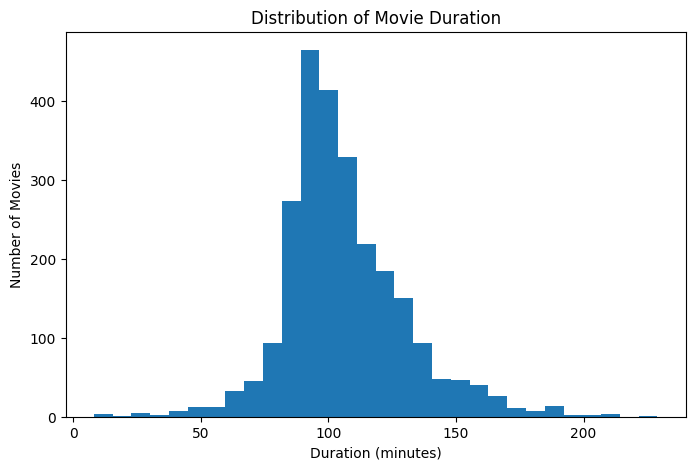

In [93]:
plt.figure(figsize=(8,5))
plt.hist(merged["duration"], bins=30)
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Duration")
plt.show()

### Interpretation of Visualization 2

The histogram shows that most movies have a duration between 80 and 120 minutes, with a peak around 90–100 minutes. This indicates that there is a common standard duration for movies.

The distribution appears approximately bell-shaped, suggesting that extremely short or very long movies are less common. A small number of outliers can be observed, but they do not significantly affect the overall pattern.

### Final Answer to the Research Question

The analysis compared Netflix movies against non-Netflix movies in terms of 
ratings and duration. The bar chart shows whether Netflix-listed movies tend 
to receive higher or lower average ratings compared to the broader movie dataset.

The duration histogram reveals that most movies — whether on Netflix or not — 
follow a standard runtime between 80 and 120 minutes, suggesting Netflix does 
not significantly differ in this aspect.

Overall, the findings suggest that Netflix movies share similar characteristics 
with the general movie population, though slight differences in ratings may 
reflect Netflix's content curation strategy.

## Next Steps

If I had more time, I would explore additional variables such as genres and 
release trends to gain deeper insights into movie performance. I would also 
investigate more advanced matching techniques such as fuzzy matching instead 
of relying only on title matching, to improve the size and accuracy of the 
merged dataset. Additionally, I would include more datasets to enrich the 
analysis and provide a broader perspective on movie characteristics. Finally, 
I would further investigate the remaining missing values in the release_date 
column and explore whether they follow any pattern.